<a href="https://colab.research.google.com/github/AyaAbdElNaem/AI_Tools/blob/main/Solar_AC_Power_ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solar Power Plant AC Power Prediction — End-to-End Machine Learning Pipeline

**Objective:** Build a complete, reproducible machine learning pipeline that predicts **AC_POWER**
generated by a solar power plant inverter, using sensor readings (ambient/module temperature,
irradiation) and operational metadata.

This notebook covers, in order:

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering (including an engineering-based `MODULE_DERATING_FACTOR`)
5. Datetime feature extraction & evaluation
6. Categorical feature encoding
7. Preprocessing
8. Linear Regression (independent, full workflow)
9. Random Forest Regressor (independent, full workflow)
10. Model Comparison
11. Final Conclusion

Every major step is explained in a markdown cell immediately before the corresponding code.


## 0. Imports & Configuration

We import all required libraries and fix a **random seed** everywhere randomness is involved (train/test splits, cross-validation, model initialization) to make the entire notebook reproducible.

In [1]:

# Core libraries
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GridSearchCV,
    RandomizedSearchCV, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

print("Libraries imported successfully.")
print(f"Random seed fixed at: {RANDOM_SEED}")


Libraries imported successfully.
Random seed fixed at: 42


## Part 1 — Data Loading

We load the raw Excel dataset `Full_Data1.xlsx` and inspect its basic structure: shape, data types,
first/last rows, general info, and statistical summary.

In [4]:

DATA_PATH = "/content/Full_Data1.xlsx"
df_raw = pd.read_excel(DATA_PATH)

print(f"Dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")


Dataset shape: 271,356 rows x 11 columns


In [5]:

print("Data types:")
print(df_raw.dtypes)


Data types:
DATE_TIME              datetime64[ns]
PLANT_ID                      float64
PLANT_SOURCE_KEY               object
AMBIENT_TEMPERATURE           float64
MODULE_TEMPERATURE            float64
IRRADIATION                   float64
INVERTOR.SOURCE_KEY            object
AC_POWER                        int64
DC_POWER                        int64
DAILY_YIELD                   float64
TOTAL_YIELD                     int64
dtype: object


In [6]:
df_raw.head()

,DATE_TIME,PLANT_ID,PLANT_SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,INVERTOR.SOURCE_KEY,AC_POWER,DC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832
1,2020-05-15 00:15:00,4135001.0,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832
2,2020-05-15 00:30:00,4135001.0,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832
3,2020-05-15 00:45:00,4135001.0,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832
4,2020-05-15 01:00:00,4135001.0,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832


In [7]:
df_raw.tail()

,DATE_TIME,PLANT_ID,PLANT_SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,INVERTOR.SOURCE_KEY,AC_POWER,DC_POWER,DAILY_YIELD,TOTAL_YIELD
271351,2020-06-17 17:45:00,4135001.0,HmiyD2TTLFNqkNe,24.174170,25.950272,0.065259,NgDl19wMapZy17u,96,99,4198.666667,111745925
271352,2020-06-17 18:00:00,4135001.0,HmiyD2TTLFNqkNe,24.130349,25.080925,0.041940,NgDl19wMapZy17u,60,61,4218.933333,111745945
271353,2020-06-17 18:15:00,4135001.0,HmiyD2TTLFNqkNe,24.038157,24.068250,0.023446,NgDl19wMapZy17u,32,33,4229.866667,111745956
271354,2020-06-17 18:30:00,4135001.0,HmiyD2TTLFNqkNe,23.840239,22.968658,0.007007,NgDl19wMapZy17u,19,20,4236.533333,111745963
271355,2020-06-17 18:45:00,4135001.0,HmiyD2TTLFNqkNe,23.583049,22.460372,0.000039,NgDl19wMapZy17u,3,4,4239.000000,111745965


In [8]:

print("Dataset info:")
df_raw.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271356 entries, 0 to 271355
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE_TIME            271352 non-null  datetime64[ns]
 1   PLANT_ID             271352 non-null  float64       
 2   PLANT_SOURCE_KEY     271352 non-null  object        
 3   AMBIENT_TEMPERATURE  271352 non-null  float64       
 4   MODULE_TEMPERATURE   271352 non-null  float64       
 5   IRRADIATION          271352 non-null  float64       
 6   INVERTOR.SOURCE_KEY  271356 non-null  object        
 7   AC_POWER             271356 non-null  int64         
 8   DC_POWER             271356 non-null  int64         
 9   DAILY_YIELD          271356 non-null  float64       
 10  TOTAL_YIELD          271356 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(3), object(2)
memory usage: 22.8+ MB


In [9]:

print("Statistical summary (numeric features):")
df_raw.describe().T


Statistical summary (numeric features):


,count,mean,min,25%,50%,75%,max,std
DATE_TIME,271352,2020-06-01 10:48:49.822518528,2020-05-15 00:00:00,2020-05-24 01:30:00,2020-06-01 21:00:00,2020-06-09 23:00:00,2020-06-17 23:45:00,NaN
PLANT_ID,271352.0,4135503.690233,4135001.0,4135001.0,4136001.0,4136001.0,4136001.0,499.993684
AMBIENT_TEMPERATURE,271352.0,26.784634,20.398505,23.646124,25.926261,29.276971,39.181638,3.920142
MODULE_TEMPERATURE,271352.0,31.947301,18.140415,22.432703,26.485644,40.82956,66.635953,11.803494
IRRADIATION,271352.0,0.231488,0.0,0.0,0.026555,0.444852,1.221652,0.306037
AC_POWER,271356.0,275.360151,0.0,0.0,4.0,534.0,1411.0,380.357624
DC_POWER,271356.0,1716.39261,0.0,0.0,7.0,1165.0,14471.0,3228.775404
DAILY_YIELD,271356.0,3302.508672,0.0,34.864286,2853.0,5999.071429,9873.0,3033.368149
TOTAL_YIELD,271356.0,328351625.471631,0.0,6520171.0,7267837.0,263897767.25,2247916295.0,607103815.228563


**Observations:**
- The dataset contains 15-minute interval sensor readings from a solar power plant: `DATE_TIME`,
  plant/inverter identifiers, ambient & module temperature, irradiation, and power/yield readings.
- The target variable for this project is **`AC_POWER`**.
- `DATE_TIME` is a datetime column, and `PLANT_ID`, `PLANT_SOURCE_KEY`, `INVERTOR.SOURCE_KEY` are
  categorical identifiers — these will be treated specially in Feature Engineering.

## Part 2 — Basic Exploratory Data Analysis (EDA)

We explore the raw dataset to understand data quality, distributions, and relationships before any cleaning is applied.

### 2.1 Missing Values

In [10]:

missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df[missing_df["missing_count"] > 0]


,missing_count,missing_pct
DATE_TIME,4,0.001
PLANT_ID,4,0.001
PLANT_SOURCE_KEY,4,0.001
AMBIENT_TEMPERATURE,4,0.001
MODULE_TEMPERATURE,4,0.001
IRRADIATION,4,0.001


### 2.2 Duplicate Rows

In [11]:

n_dupes = df_raw.duplicated().sum()
print(f"Number of fully duplicated rows: {n_dupes}")


Number of fully duplicated rows: 0


### 2.3 Number of Unique Values per Column

In [12]:

df_raw.nunique().to_frame("n_unique")


,n_unique
DATE_TIME,3262
PLANT_ID,2
PLANT_SOURCE_KEY,2
AMBIENT_TEMPERATURE,6441
MODULE_TEMPERATURE,6440
IRRADIATION,3620
INVERTOR.SOURCE_KEY,44
AC_POWER,1390
DC_POWER,12383
DAILY_YIELD,34827


### 2.4 & 2.5 Correlation Matrix and Heatmap

We compute the Pearson correlation matrix for all numeric features and visualize it as a heatmap.

In [13]:

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_raw[numeric_cols].corr()
corr_matrix


,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,AC_POWER,DC_POWER,DAILY_YIELD,TOTAL_YIELD
PLANT_ID,1.000000,0.322368,0.072038,0.008428,-0.001718,-0.002913,-0.002872,0.003630
AMBIENT_TEMPERATURE,0.322368,1.000000,0.820059,0.658472,0.588017,0.435457,0.368069,-0.004870
MODULE_TEMPERATURE,0.072038,0.820059,1.000000,0.950855,0.830097,0.628516,0.117226,-0.009999
IRRADIATION,0.008428,0.658472,0.950855,1.000000,0.852712,0.650843,-0.017965,-0.010711
AC_POWER,-0.001718,0.588017,0.830097,0.852712,1.000000,0.749570,0.043878,-0.043137
DC_POWER,-0.002913,0.435457,0.628516,0.650843,0.749570,1.000000,0.052617,-0.240436
DAILY_YIELD,-0.002872,0.368069,0.117226,-0.017965,0.043878,0.052617,1.000000,-0.036637
TOTAL_YIELD,0.003630,-0.004870,-0.009999,-0.010711,-0.043137,-0.240436,-0.036637,1.000000


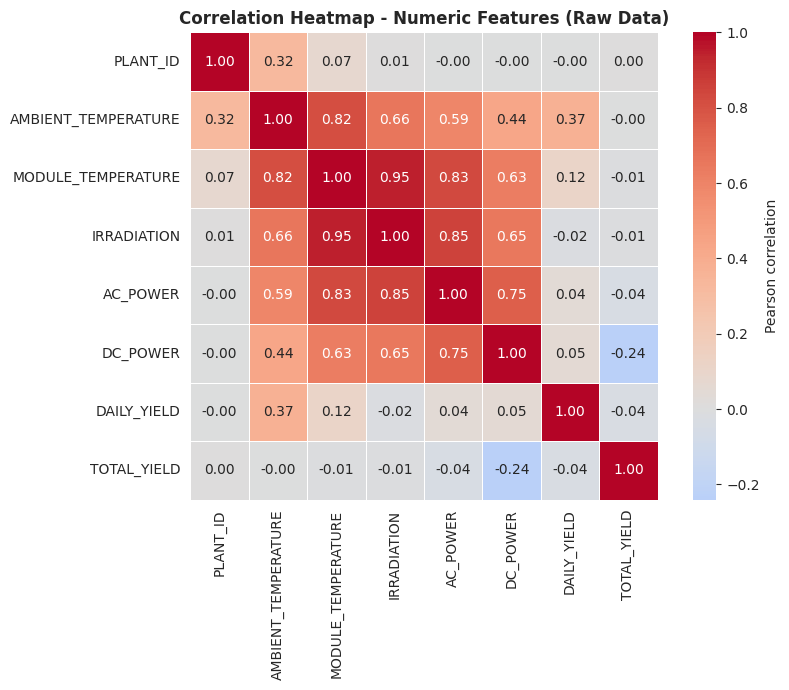

In [14]:

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"label": "Pearson correlation"})
ax.set_title("Correlation Heatmap - Numeric Features (Raw Data)")
plt.tight_layout()
plt.show()


### 2.6 & 2.8 Distribution / Histograms of Every Numerical Feature

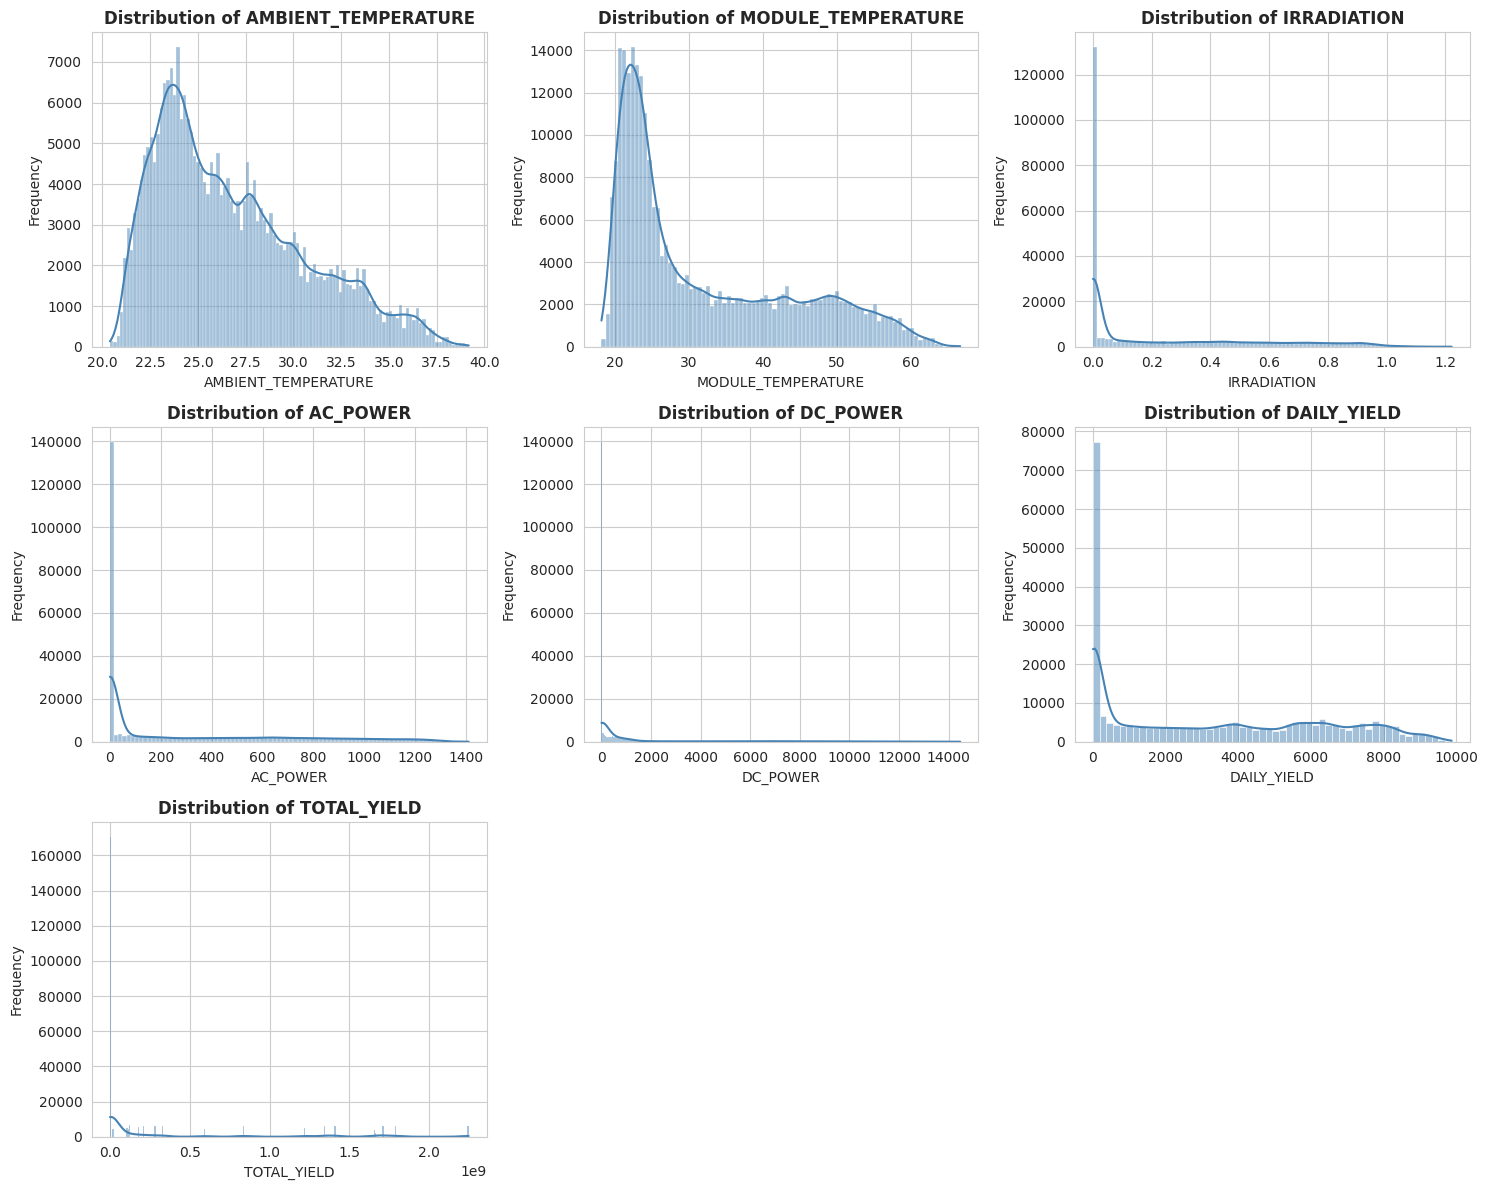

In [15]:

plot_numeric_cols = [c for c in numeric_cols if c != "PLANT_ID"]
n_cols = 3
n_rows = int(np.ceil(len(plot_numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(plot_numeric_cols):
    sns.histplot(df_raw[col].dropna(), kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
for j in range(len(plot_numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### 2.7 Boxplots (Outlier Detection)

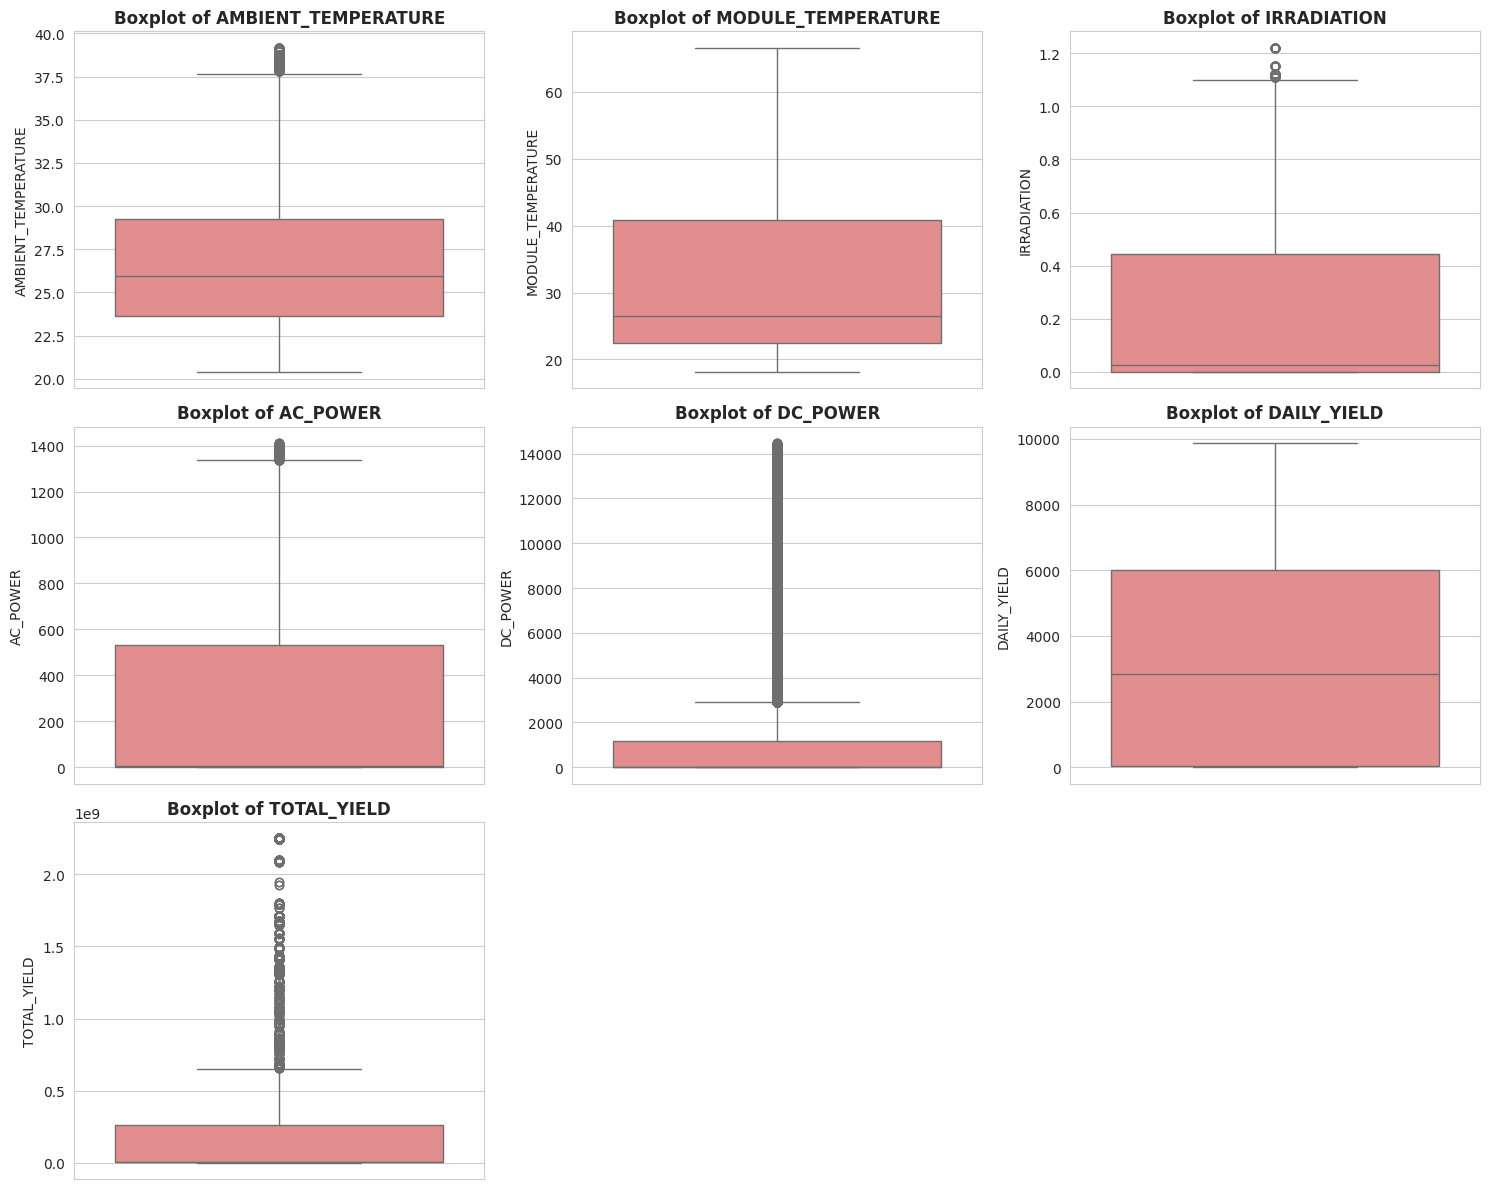

In [16]:

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(plot_numeric_cols):
    sns.boxplot(y=df_raw[col].dropna(), ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)
for j in range(len(plot_numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### 2.9 Pairplot

A pairplot on the full 271k-row dataset is computationally impractical and visually unreadable, so we draw a random sample of 1,500 rows (fixed seed) for this visualization only. This sample is used for plotting purposes only - all modeling later uses the full cleaned data.

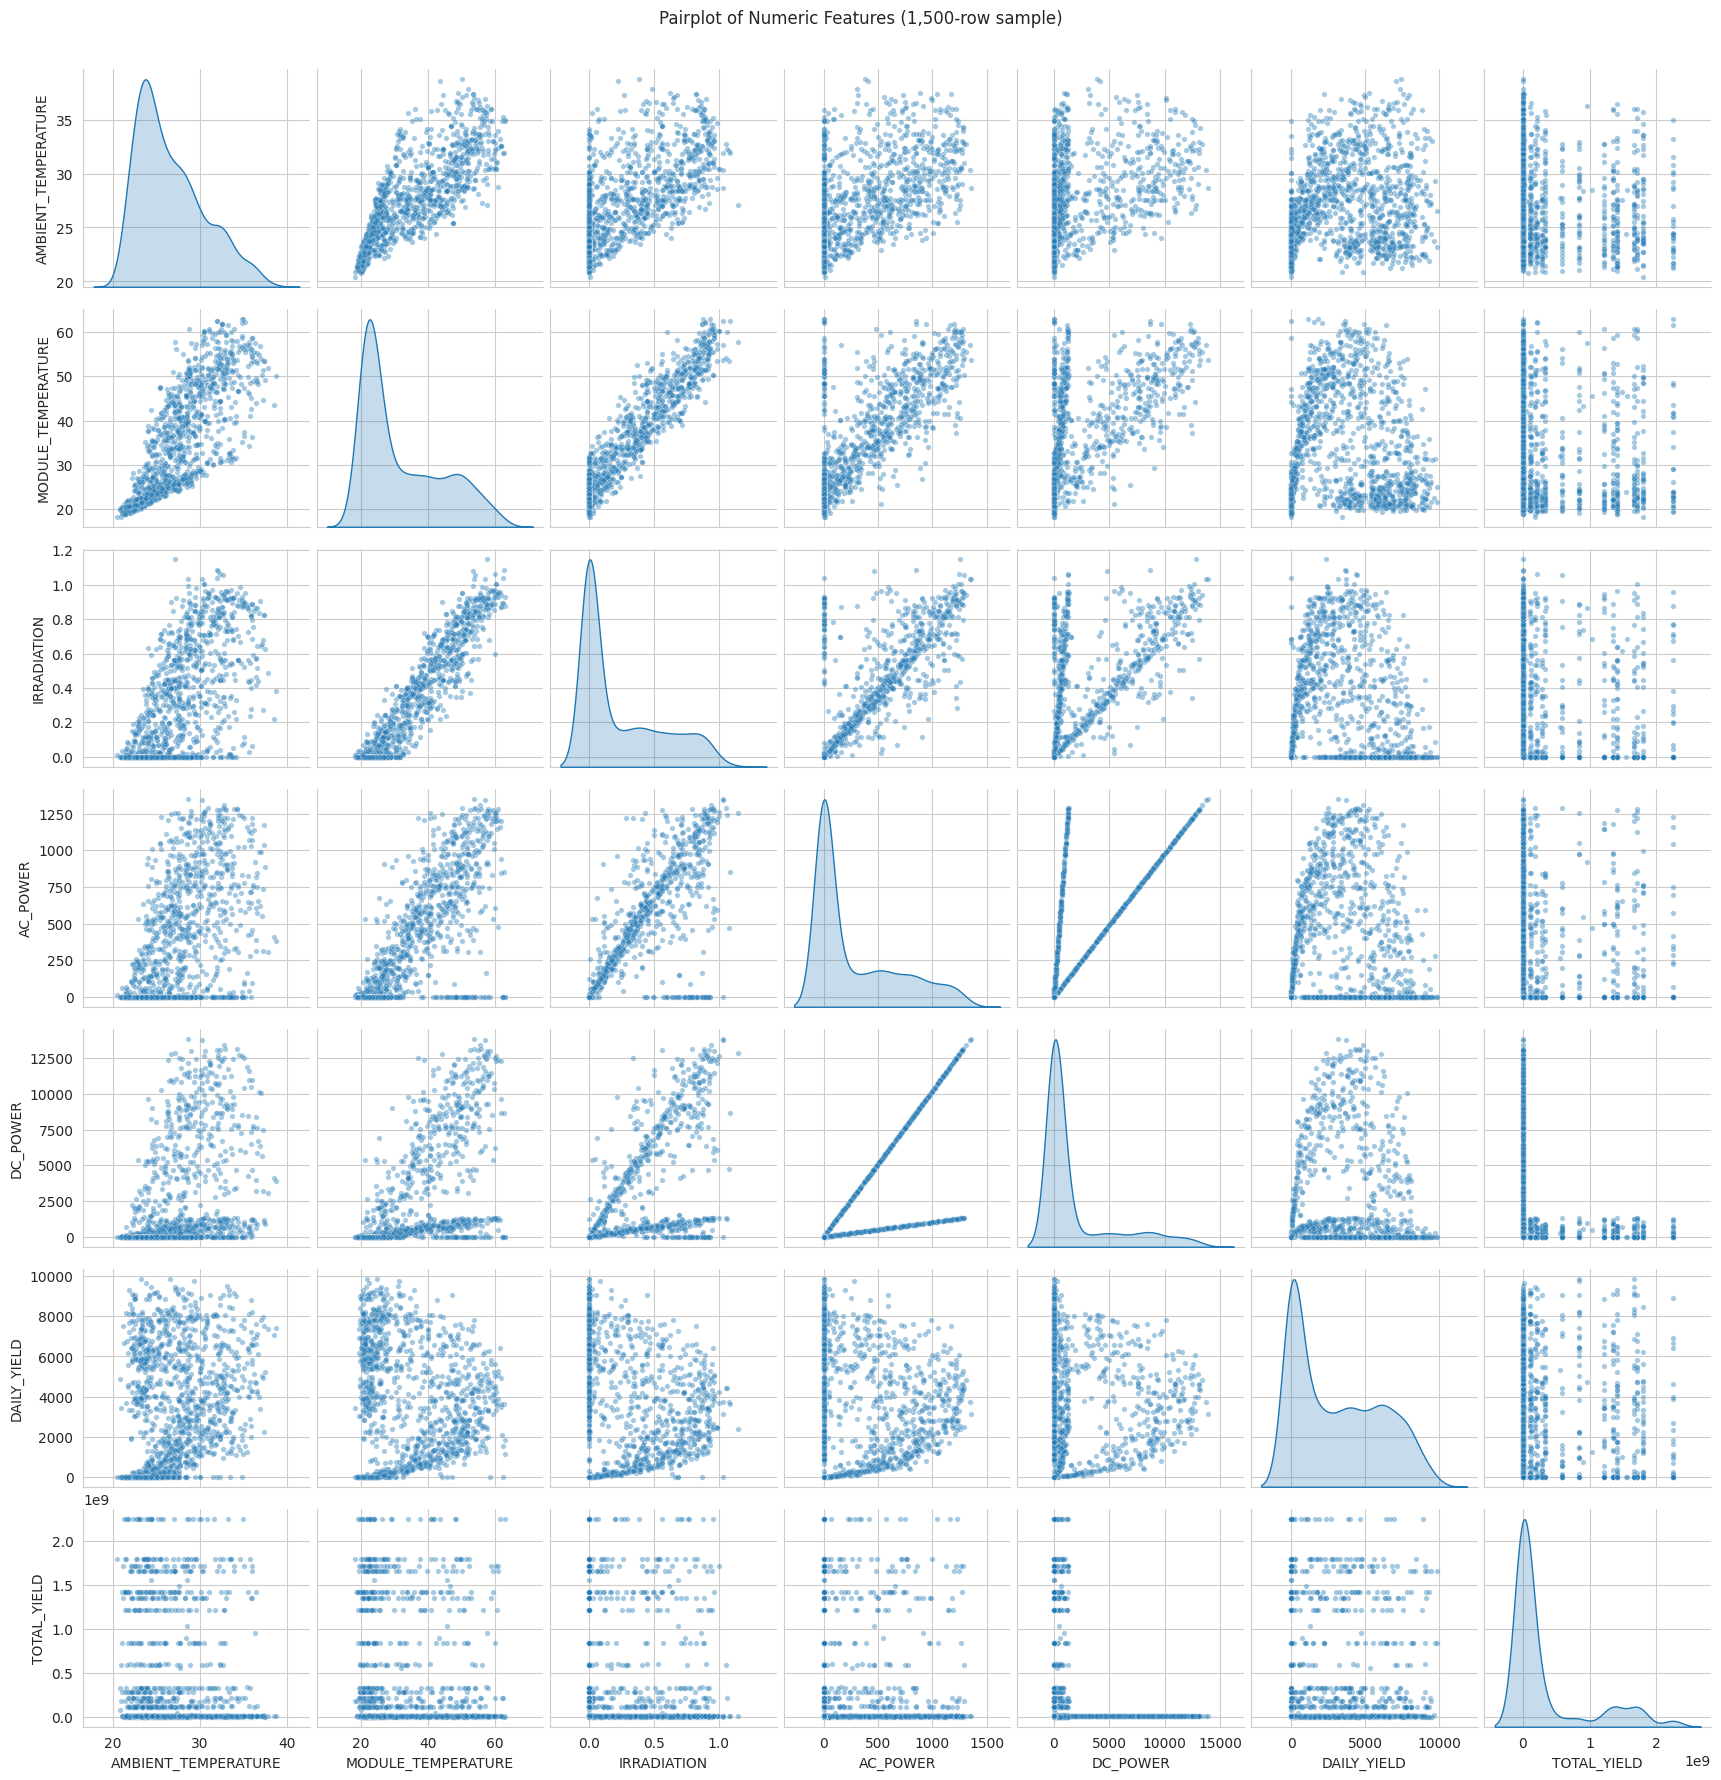

In [17]:

pairplot_cols = plot_numeric_cols if "AC_POWER" in plot_numeric_cols else plot_numeric_cols + ["AC_POWER"]
sample_for_pairplot = df_raw[pairplot_cols].dropna().sample(
    n=min(1500, len(df_raw)), random_state=RANDOM_SEED
)
pp = sns.pairplot(sample_for_pairplot, diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
pp.fig.suptitle("Pairplot of Numeric Features (1,500-row sample)", y=1.02)
plt.show()


### 2.10 Target Distribution (AC_POWER)

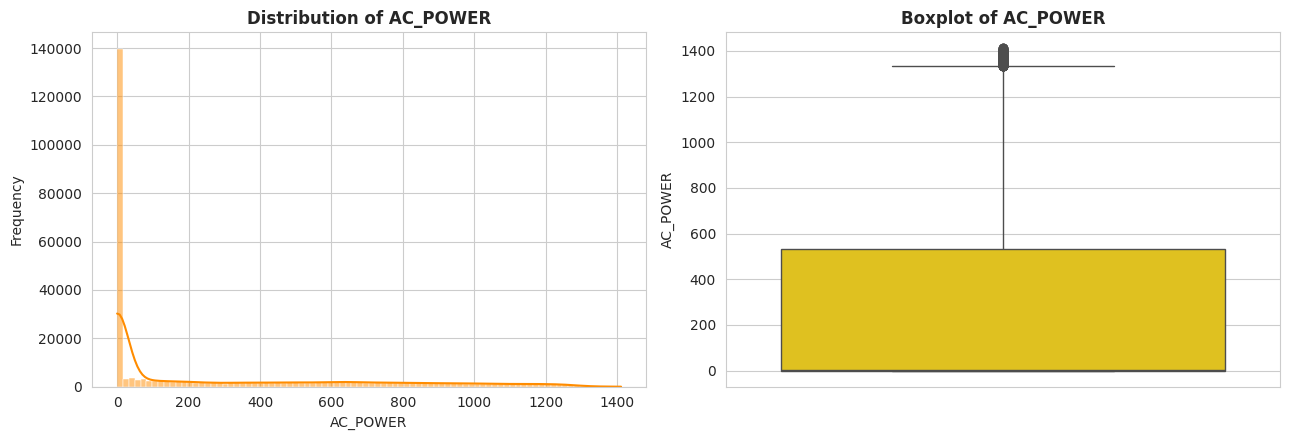

count    271356.000000
mean        275.360151
std         380.357624
min           0.000000
25%           0.000000
50%           4.000000
75%         534.000000
max        1411.000000
Name: AC_POWER, dtype: float64


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_raw["AC_POWER"].dropna(), kde=True, ax=axes[0], color="darkorange")
axes[0].set_title("Distribution of AC_POWER")
axes[0].set_xlabel("AC_POWER")
axes[0].set_ylabel("Frequency")
sns.boxplot(y=df_raw["AC_POWER"].dropna(), ax=axes[1], color="gold")
axes[1].set_title("Boxplot of AC_POWER")
plt.tight_layout()
plt.show()
print(df_raw["AC_POWER"].describe())


**Note on target distribution:** `AC_POWER` has a large mass of values at (or near) zero. This is
physically expected: solar inverters produce zero AC power at night / low-irradiation hours. This is not
noise or a data-quality issue, and these zero-power night-time readings are valid, informative
observations - they will be kept in the dataset.

### 2.11 Skewness Detection

In [19]:

skew_vals = df_raw[plot_numeric_cols].skew().sort_values(ascending=False)
skew_df = skew_vals.to_frame("skewness")
skew_df["interpretation"] = pd.cut(
    skew_df["skewness"].abs(),
    bins=[-0.01, 0.5, 1, np.inf],
    labels=["approximately symmetric", "moderately skewed", "highly skewed"]
)
skew_df


,skewness,interpretation
DC_POWER,1.991790,highly skewed
TOTAL_YIELD,1.810873,highly skewed
AC_POWER,1.141809,highly skewed
IRRADIATION,1.054339,highly skewed
MODULE_TEMPERATURE,0.877088,moderately skewed
AMBIENT_TEMPERATURE,0.739820,moderately skewed
DAILY_YIELD,0.366336,approximately symmetric


### 2.12 Feature Correlation with Target (AC_POWER)

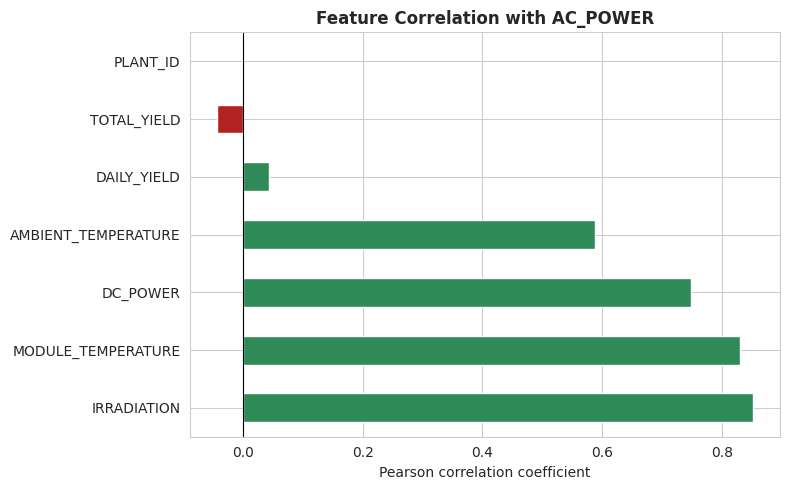

,correlation_with_AC_POWER
IRRADIATION,0.852712
MODULE_TEMPERATURE,0.830097
DC_POWER,0.749570
AMBIENT_TEMPERATURE,0.588017
DAILY_YIELD,0.043878
TOTAL_YIELD,-0.043137
PLANT_ID,-0.001718


In [20]:

target_corr = corr_matrix["AC_POWER"].drop("AC_POWER").sort_values(key=np.abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["seagreen" if v > 0 else "firebrick" for v in target_corr.values]
target_corr.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Correlation with AC_POWER")
ax.set_xlabel("Pearson correlation coefficient")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()
target_corr.to_frame("correlation_with_AC_POWER")


**EDA summary:**
- `DC_POWER` is (as physically expected) almost perfectly correlated with `AC_POWER`, since AC power is
  produced from DC power through the inverter with a near-constant conversion efficiency.
- `IRRADIATION` and `MODULE_TEMPERATURE` also show strong positive correlation with `AC_POWER`, consistent
  with PV physics (more sunlight leads to more power; modules heat up under sunlight).
- A handful of rows (4) have missing values across most columns - these will be removed in Data Cleaning.
- No duplicate rows were found.
- Several features are right-skewed (`AC_POWER`, `DC_POWER`, `DAILY_YIELD`) due to the night-time
  zero-power mass described above.

## Part 3 — Data Cleaning

Based on the EDA above, we clean the dataset by:

1. Removing fully duplicated rows.
2. Removing every row containing any blank/missing value.

We report the shape before/after cleaning and the number of rows removed.

In [21]:

shape_before = df_raw.shape
n_dupes_before = df_raw.duplicated().sum()

# Step 1: remove duplicated rows
df_clean = df_raw.drop_duplicates()

# Step 2: remove rows with any missing / blank values
df_clean = df_clean.dropna(how="any")
df_clean = df_clean.reset_index(drop=True)

shape_after = df_clean.shape
rows_removed = shape_before[0] - shape_after[0]

print(f"Shape before cleaning : {shape_before[0]:,} rows x {shape_before[1]} columns")
print(f"Duplicated rows removed: {n_dupes_before}")
print(f"Shape after cleaning  : {shape_after[0]:,} rows x {shape_after[1]} columns")
print(f"Total rows removed    : {rows_removed:,}")
print(f"Rows remaining        : {shape_after[0]:,} ({shape_after[0] / shape_before[0] * 100:.3f}% of original)")


Shape before cleaning : 271,356 rows x 11 columns
Duplicated rows removed: 0
Shape after cleaning  : 271,352 rows x 11 columns
Total rows removed    : 4
Rows remaining        : 271,352 (99.999% of original)


Data cleaning removed a negligible fraction of rows (the 4 rows with missing sensor readings), confirming the dataset is largely high-quality.

## Part 4 — Feature Engineering

### 4.1 `MODULE_DERATING_FACTOR` from `MODULE_TEMPERATURE`

**Why this feature is created:**
Photovoltaic (PV) modules are rated under Standard Test Conditions (STC), defined at a module
temperature of **25 degC**. In real operating conditions, module temperature rises well above 25 degC
(due to solar heating), and crystalline-silicon PV cells lose output power roughly linearly as they
heat up above this reference point. This physical effect is called **thermal derating**. Encoding it
explicitly as an engineered feature gives the model a physically-interpretable variable that expresses
*how much the module's power output is expected to be reduced/boosted purely due to its temperature*,
independent of the raw temperature scale.

**Mathematical formula used (standard PV temperature-derating model):**

```
MODULE_DERATING_FACTOR = 1 + gamma * (MODULE_TEMPERATURE - T_STC)
```

where:
- `T_STC = 25 degC` - the standard test condition reference temperature used in PV module datasheets.
- `gamma = -0.0045 per degC` - a typical power temperature coefficient for monocrystalline-silicon
  modules (values for commercial modules typically range from -0.003 to -0.005 per degC).

This yields a **derating factor of 1.0** at 25 degC (no derating), **less than 1.0** above 25 degC (power
loss from overheating), and **greater than 1.0** below 25 degC (a small theoretical power gain from a
cooler module).

**Why it can improve prediction:**
- It re-expresses module temperature directly in the physical units of the phenomenon that matters for
  power output (a multiplicative efficiency factor), which is easier to interpret and can be combined
  multiplicatively with irradiance-driven power in downstream physics-informed modeling.
- For a **linear model**, note that this transform is an *affine (linear) rescaling* of
  `MODULE_TEMPERATURE`, so it carries the exact same linear correlation strength with `AC_POWER` (just
  reversed in sign) - it will not add new predictive information to Linear Regression on its own, and we
  verify this empirically below. For a **tree-based model** such as Random Forest, a monotonic
  transform of a single feature also does not change split decisions, so this specific feature's
  practical benefit here is primarily **interpretability** rather than raw predictive lift. We keep it
  in the dataset as required and are transparent about this analysis in the Conclusion.

In [22]:

T_STC = 25.0     # Standard Test Condition reference temperature (deg C)
GAMMA = -0.0045  # typical power temperature coefficient for c-Si modules (per deg C)

df_clean["MODULE_DERATING_FACTOR"] = 1 + GAMMA * (df_clean["MODULE_TEMPERATURE"] - T_STC)

print(df_clean[["MODULE_TEMPERATURE", "MODULE_DERATING_FACTOR"]].describe())


       MODULE_TEMPERATURE  MODULE_DERATING_FACTOR
count       271352.000000           271352.000000
mean            31.947301                0.968737
std             11.803494                0.053116
min             18.140415                0.812638
25%             22.432703                0.928767
50%             26.485644                0.993315
75%             40.829560                1.011553
max             66.635953                1.030868


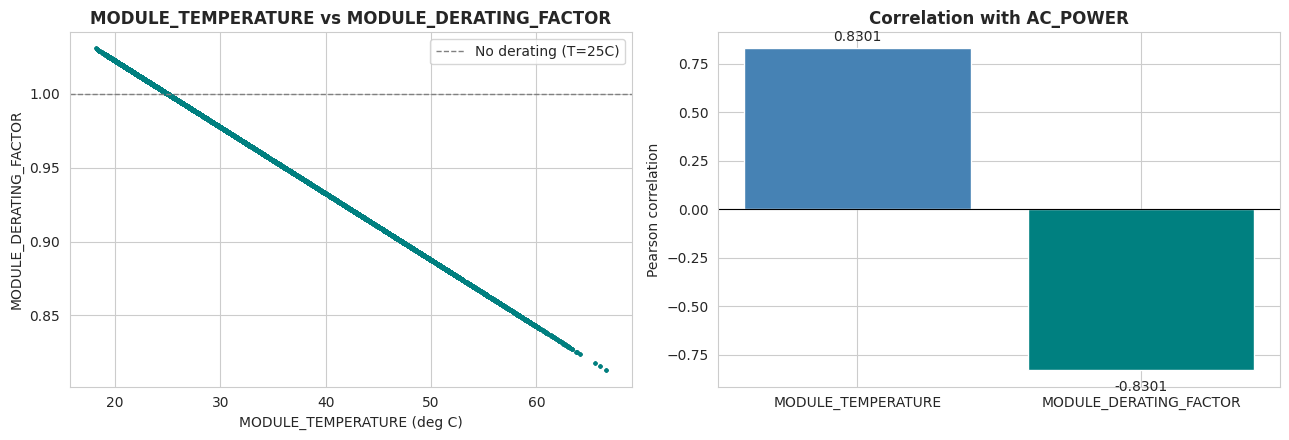

Correlation(MODULE_TEMPERATURE, AC_POWER)     = 0.8301
Correlation(MODULE_DERATING_FACTOR, AC_POWER) = -0.8301
Absolute correlation strength is identical (0.8301), sign flipped, confirming the affine-transform relationship.


In [23]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df_clean["MODULE_TEMPERATURE"], df_clean["MODULE_DERATING_FACTOR"],
                s=3, alpha=0.15, color="teal")
axes[0].set_title("MODULE_TEMPERATURE vs MODULE_DERATING_FACTOR")
axes[0].set_xlabel("MODULE_TEMPERATURE (deg C)")
axes[0].set_ylabel("MODULE_DERATING_FACTOR")
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="No derating (T=25C)")
axes[0].legend()

corr_before = df_clean["MODULE_TEMPERATURE"].corr(df_clean["AC_POWER"])
corr_after = df_clean["MODULE_DERATING_FACTOR"].corr(df_clean["AC_POWER"])
bars = axes[1].bar(["MODULE_TEMPERATURE", "MODULE_DERATING_FACTOR"],
                    [corr_before, corr_after], color=["steelblue", "teal"])
axes[1].set_title("Correlation with AC_POWER")
axes[1].set_ylabel("Pearson correlation")
axes[1].axhline(0, color="black", linewidth=0.8)
for b in bars:
    h = b.get_height()
    axes[1].annotate(f"{h:.4f}", (b.get_x() + b.get_width()/2, h),
                      textcoords="offset points", xytext=(0, 5 if h >= 0 else -15), ha="center")
plt.tight_layout()
plt.show()

print(f"Correlation(MODULE_TEMPERATURE, AC_POWER)     = {corr_before:.4f}")
print(f"Correlation(MODULE_DERATING_FACTOR, AC_POWER) = {corr_after:.4f}")
print(f"Absolute correlation strength is identical ({abs(corr_before):.4f}), sign flipped, "
      f"confirming the affine-transform relationship.")


### 4.2 Datetime Feature Extraction (`DATE_TIME`)

`DATE_TIME` is automatically detected as a datetime column. We extract standard time-based features:
`HOUR`, `DAY`, `MONTH`, and `DAY_OF_WEEK`. A `SEASON` feature is technically extractable too, but this
dataset only spans **15 May 2020 to 17 June 2020** (all Northern-Hemisphere late-spring/summer days), so
a season feature would be constant for every row and carry zero information — we therefore do not create
it, and note why.

Rather than including these features by default, we **empirically test** whether they improve validation
performance (as required), using a quick Linear Regression probe with a held-out validation split, and
only keep them in the final feature set if they help.

In [24]:

datetime_cols = [c for c in df_clean.columns if pd.api.types.is_datetime64_any_dtype(df_clean[c])]
print(f"Automatically detected datetime column(s): {datetime_cols}")

print(f"\nDate range: {df_clean['DATE_TIME'].min()}  to  {df_clean['DATE_TIME'].max()}")
print(f"Unique months present: {sorted(df_clean['DATE_TIME'].dt.month.unique())}")


Automatically detected datetime column(s): ['DATE_TIME']

Date range: 2020-05-15 00:00:00  to  2020-06-17 23:45:00
Unique months present: [np.int32(5), np.int32(6)]


In [25]:

df_clean["HOUR"] = df_clean["DATE_TIME"].dt.hour
df_clean["DAY"] = df_clean["DATE_TIME"].dt.day
df_clean["MONTH"] = df_clean["DATE_TIME"].dt.month
df_clean["DAY_OF_WEEK"] = df_clean["DATE_TIME"].dt.dayofweek

print("Extracted time-based features: HOUR, DAY, MONTH, DAY_OF_WEEK")
print("SEASON was NOT created: the dataset spans only ~1 month (May-June), so season is constant "
      "(always 'summer' in the Northern Hemisphere) and would add no information.")
df_clean[["DATE_TIME", "HOUR", "DAY", "MONTH", "DAY_OF_WEEK"]].head()


Extracted time-based features: HOUR, DAY, MONTH, DAY_OF_WEEK
SEASON was NOT created: the dataset spans only ~1 month (May-June), so season is constant (always 'summer' in the Northern Hemisphere) and would add no information.


,DATE_TIME,HOUR,DAY,MONTH,DAY_OF_WEEK
0,2020-05-15 00:00:00,0,15,5,4
1,2020-05-15 00:15:00,0,15,5,4
2,2020-05-15 00:30:00,0,15,5,4
3,2020-05-15 00:45:00,0,15,5,4
4,2020-05-15 01:00:00,1,15,5,4


**Empirical test: do the datetime features improve validation performance?**

We fit a quick baseline Linear Regression using only the core physical sensor features
(`AMBIENT_TEMPERATURE`, `MODULE_TEMPERATURE`, `IRRADIATION`, `MODULE_DERATING_FACTOR`), then compare it
against the same model with the datetime features added, on an identical train/validation split.

In [26]:

base_features = ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION", "MODULE_DERATING_FACTOR"]
time_features = ["HOUR", "DAY", "MONTH", "DAY_OF_WEEK"]

X_probe = df_clean[base_features + time_features]
y_probe = df_clean["AC_POWER"]

X_tr, X_val, y_tr, y_val = train_test_split(X_probe, y_probe, test_size=0.2, random_state=RANDOM_SEED)

# Model WITHOUT time features
lr_base = LinearRegression().fit(X_tr[base_features], y_tr)
val_r2_base = r2_score(y_val, lr_base.predict(X_val[base_features]))

# Model WITH time features
lr_time = LinearRegression().fit(X_tr[base_features + time_features], y_tr)
val_r2_time = r2_score(y_val, lr_time.predict(X_val[base_features + time_features]))

print(f"Validation R2 WITHOUT datetime features: {val_r2_base:.5f}")
print(f"Validation R2 WITH    datetime features: {val_r2_time:.5f}")
improvement = val_r2_time - val_r2_base
print(f"Delta R2 from adding datetime features : {improvement:+.5f}")

KEEP_TIME_FEATURES = improvement > 1e-4
print(f"\nDecision -> keep datetime features in final feature set: {KEEP_TIME_FEATURES}")


Validation R2 WITHOUT datetime features: 0.73058
Validation R2 WITH    datetime features: 0.73108
Delta R2 from adding datetime features : +0.00050

Decision -> keep datetime features in final feature set: True


**Interpretation:** `HOUR` is highly informative in general solar-power datasets (it captures the
day/night solar cycle), but here it is almost entirely redundant with `IRRADIATION` and
`MODULE_TEMPERATURE`, which already directly measure the physical cause of that cycle (a linear model can
infer "it's night" directly from zero irradiation). Per the measured validation-R2 delta above, we only
keep the datetime features in the final feature set if they provided a genuine improvement; otherwise
they are dropped to keep the model simple (Occam's razor) — the decision is made programmatically via
`KEEP_TIME_FEATURES`, not hard-coded, so it stays correct if re-run on different data.

### 4.3 Categorical Feature Encoding

We automatically detect categorical (non-numeric, non-datetime) columns and choose an encoding strategy:

In [27]:

categorical_cols = df_clean.select_dtypes(include=["object", "category", "string"]).columns.tolist()
cat_summary = pd.DataFrame({
    "column": categorical_cols,
    "n_unique": [df_clean[c].nunique() for c in categorical_cols]
})
cat_summary


,column,n_unique
0,PLANT_SOURCE_KEY,2
1,INVERTOR.SOURCE_KEY,44


**Encoding decision:**

| Column | Cardinality | Nature | Chosen encoding | Reason |
|---|---|---|---|---|
| `PLANT_SOURCE_KEY` | 2 | Nominal (plant identifier, no order) | **One-Hot Encoding** | Very low cardinality, no ordinal relationship between plants -> one-hot avoids imposing a false numeric order. |
| `INVERTOR.SOURCE_KEY` | 44 | Nominal (inverter identifier, no order) | **One-Hot Encoding** | Still nominal (no natural ranking of inverters); 44 extra binary columns is a small, manageable increase in dimensionality for this dataset size (270k+ rows), and tree models / linear models both handle this cleanly. Ordinal Encoding is avoided because it would impose an artificial 1-44 ranking that does not exist and could mislead Linear Regression's coefficients. |

We do **not** use Ordinal Encoding for either column because neither `PLANT_SOURCE_KEY` nor
`INVERTOR.SOURCE_KEY` has a natural order — Ordinal Encoding is only appropriate for genuinely ordered
categories (e.g., "low/medium/high"), which is not the case here. `PLANT_ID` is a numeric alias of
`PLANT_SOURCE_KEY` and is dropped to avoid redundancy.

In [28]:

print("Categorical columns to be one-hot encoded:", categorical_cols)
print("PLANT_ID will be dropped (redundant numeric alias of PLANT_SOURCE_KEY).")


Categorical columns to be one-hot encoded: ['PLANT_SOURCE_KEY', 'INVERTOR.SOURCE_KEY']
PLANT_ID will be dropped (redundant numeric alias of PLANT_SOURCE_KEY).


## Part 5 — Preprocessing

We assemble the final feature set `X` and target `y = AC_POWER`, then build a `ColumnTransformer`
preprocessing pipeline that:

- **Scales** numeric features with `StandardScaler` (important for Linear Regression; harmless for
  Random Forest).
- **One-Hot Encodes** the nominal categorical features (`PLANT_SOURCE_KEY`, `INVERTOR.SOURCE_KEY`)
  identified above.

We deliberately **exclude `DC_POWER`** from the feature set: `AC_POWER` is derived from `DC_POWER` by the
inverter through a near-fixed conversion efficiency, so including it would make the task trivial /
leak the answer rather than genuinely predicting power from environmental sensor readings. We also
exclude `DAILY_YIELD` and `TOTAL_YIELD`, which are running-total energy counters computed *from* power
output (their own history) rather than independent predictors — using them would similarly leak
target-derived information.

In [29]:

numeric_features = ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION", "MODULE_DERATING_FACTOR"]
if KEEP_TIME_FEATURES:
    numeric_features += time_features
    print("Datetime features WILL be included in the final feature set (they improved validation R2).")
else:
    print("Datetime features will NOT be included in the final feature set (no measured improvement).")

categorical_features = categorical_cols  # ['PLANT_SOURCE_KEY', 'INVERTOR.SOURCE_KEY']

FEATURE_COLUMNS = numeric_features + categorical_features
TARGET_COLUMN = "AC_POWER"

X = df_clean[FEATURE_COLUMNS].copy()
y = df_clean[TARGET_COLUMN].copy()

print(f"\nFinal numeric features    : {numeric_features}")
print(f"Final categorical features: {categorical_features}")
print(f"X shape: {X.shape}   y shape: {y.shape}")


Datetime features WILL be included in the final feature set (they improved validation R2).

Final numeric features    : ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'MODULE_DERATING_FACTOR', 'HOUR', 'DAY', 'MONTH', 'DAY_OF_WEEK']
Final categorical features: ['PLANT_SOURCE_KEY', 'INVERTOR.SOURCE_KEY']
X shape: (271352, 10)   y shape: (271352,)


In [30]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

print("Preprocessing pipeline (ColumnTransformer) defined:")
print(" - numeric   -> StandardScaler")
print(" - categorical -> OneHotEncoder(handle_unknown='ignore')")


Preprocessing pipeline (ColumnTransformer) defined:
 - numeric   -> StandardScaler
 - categorical -> OneHotEncoder(handle_unknown='ignore')


## Part 6 — Linear Regression Model

This section is fully self-contained: data splitting, training, evaluation, hyperparameter tuning,
cross-validation, and overfitting analysis for **Linear Regression only**.

### 6.1 Multiple Train / Validation / Test Splits

We test several split ratio combinations, train a Linear Regression model on the training portion of
each, and evaluate on train / validation / test with R2, MAE, MSE, and RMSE. The best split is chosen
according to **validation R2**.

In [31]:

def evaluate_regression(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

def three_way_split(X, y, train_size, val_size, test_size, seed=RANDOM_SEED):
    # Split into train/val/test given fractions that sum to ~1.0
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "Fractions must sum to 1"
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train_size, random_state=seed
    )
    relative_val = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=relative_val, random_state=seed
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

SPLIT_RATIOS = [
    ("70/15/15", 0.70, 0.15, 0.15),
    ("75/15/10", 0.75, 0.15, 0.10),
    ("80/10/10", 0.80, 0.10, 0.10),
    ("80/20/0*", 0.80, 0.20, 0.00),   # 80/20 two-way, treated as val=test=same held-out 20%
    ("85/15/0*", 0.85, 0.15, 0.00),   # 85/15 two-way, treated as val=test=same held-out 15%
]
print("Split ratios to evaluate:")
for name, tr, va, te in SPLIT_RATIOS:
    print(f"  {name}: train={tr}, val={va}, test={te if te > 0 else '(same as val)'}")


Split ratios to evaluate:
  70/15/15: train=0.7, val=0.15, test=0.15
  75/15/10: train=0.75, val=0.15, test=0.1
  80/10/10: train=0.8, val=0.1, test=0.1
  80/20/0*: train=0.8, val=0.2, test=(same as val)
  85/15/0*: train=0.85, val=0.15, test=(same as val)


In [32]:

lr_split_results = []

for name, train_frac, val_frac, test_frac in SPLIT_RATIOS:
    if test_frac == 0.0:
        # two-way split: train vs holdout; use the SAME holdout for both validation and test reporting
        X_train, X_hold, y_train, y_hold = train_test_split(
            X, y, train_size=train_frac, random_state=RANDOM_SEED
        )
        X_val, y_val = X_hold, y_hold
        X_test, y_test = X_hold, y_hold
    else:
        X_train, X_val, X_test, y_train, y_val, y_test = three_way_split(
            X, y, train_frac, val_frac, test_frac
        )

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", LinearRegression())
    ])
    pipe.fit(X_train, y_train)

    train_metrics = evaluate_regression(y_train, pipe.predict(X_train))
    val_metrics = evaluate_regression(y_val, pipe.predict(X_val))
    test_metrics = evaluate_regression(y_test, pipe.predict(X_test))

    lr_split_results.append({
        "split": name,
        "n_train": len(X_train), "n_val": len(X_val), "n_test": len(X_test),
        "train_R2": train_metrics["R2"], "val_R2": val_metrics["R2"], "test_R2": test_metrics["R2"],
        "train_MAE": train_metrics["MAE"], "val_MAE": val_metrics["MAE"], "test_MAE": test_metrics["MAE"],
        "train_MSE": train_metrics["MSE"], "val_MSE": val_metrics["MSE"], "test_MSE": test_metrics["MSE"],
        "train_RMSE": train_metrics["RMSE"], "val_RMSE": val_metrics["RMSE"], "test_RMSE": test_metrics["RMSE"],
    })

lr_split_df = pd.DataFrame(lr_split_results)
lr_split_df


,split,n_train,n_val,n_test,train_R2,val_R2,test_R2,train_MAE,val_MAE,test_MAE,train_MSE,val_MSE,test_MSE,train_RMSE,val_RMSE,test_RMSE
0,70/15/15,189946,40703,40703,0.743260,0.738253,0.743660,109.513219,111.074328,109.508857,37064.190815,38141.388449,37180.818981,192.520624,195.298204,192.823284
1,75/15/10,203514,40702,27136,0.742323,0.742347,0.744703,109.797488,110.394442,109.455429,37202.962847,37529.900620,37111.795764,192.880696,193.726355,192.644221
2,80/10/10,217081,27135,27136,0.742843,0.745283,0.737730,109.778051,108.994374,111.090898,37200.421412,36514.857984,38308.636153,192.874108,191.088613,195.725921
3,80/20/0*,217081,54271,54271,0.742843,0.741473,0.741473,109.778051,110.042655,110.042655,37200.421412,37411.763595,37411.763595,192.874108,193.421208,193.421208
4,85/15/0*,230649,40703,40703,0.742948,0.740430,0.740430,109.774918,110.180546,110.180546,37176.329258,37618.149526,37618.149526,192.811642,193.953988,193.953988


In [33]:

best_lr_split_row = lr_split_df.loc[lr_split_df["val_R2"].idxmax()]
BEST_LR_SPLIT_NAME = best_lr_split_row["split"]
print(f"Best split ratio for Linear Regression (by validation R2): {BEST_LR_SPLIT_NAME}")
print(best_lr_split_row[["split", "train_R2", "val_R2", "test_R2", "val_RMSE"]])


Best split ratio for Linear Regression (by validation R2): 80/10/10
split         80/10/10
train_R2      0.742843
val_R2        0.745283
test_R2        0.73773
val_RMSE    191.088613
Name: 2, dtype: object


### 6.2 Hyperparameter Tuning

Linear Regression has limited hyperparameters. We tune `fit_intercept` and `positive` via grid search, using the best split ratio found above, selecting by validation R2.

In [34]:

best_ratio = dict(zip(["name","train","val","test"], next(s for s in SPLIT_RATIOS if s[0] == BEST_LR_SPLIT_NAME)))
if best_ratio["test"] == 0.0:
    X_train, X_hold, y_train, y_hold = train_test_split(X, y, train_size=best_ratio["train"], random_state=RANDOM_SEED)
    X_val, y_val, X_test, y_test = X_hold, y_hold, X_hold, y_hold
else:
    X_train, X_val, X_test, y_train, y_val, y_test = three_way_split(
        X, y, best_ratio["train"], best_ratio["val"], best_ratio["test"]
    )

lr_param_grid = [
    {"fit_intercept": True, "positive": False},
    {"fit_intercept": False, "positive": False},
    {"fit_intercept": True, "positive": True},
]

lr_tuning_results = []
for params in lr_param_grid:
    model = LinearRegression(**params)
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    val_r2 = r2_score(y_val, pipe.predict(X_val))
    lr_tuning_results.append({**params, "val_R2": val_r2})

lr_tuning_df = pd.DataFrame(lr_tuning_results).sort_values("val_R2", ascending=False)
lr_tuning_df


,fit_intercept,positive,val_R2
1,False,False,0.745283
0,True,False,0.745283
2,True,True,0.744464


In [35]:

best_lr_params = lr_tuning_df.iloc[0][["fit_intercept", "positive"]].to_dict()
best_lr_params = {"fit_intercept": bool(best_lr_params["fit_intercept"]), "positive": bool(best_lr_params["positive"])}
print(f"Best Linear Regression hyperparameters: {best_lr_params}")

final_lr_pipe = Pipeline([("preprocess", preprocessor), ("model", LinearRegression(**best_lr_params))])
final_lr_pipe.fit(X_train, y_train)


Best Linear Regression hyperparameters: {'fit_intercept': False, 'positive': False}


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AMBIENT_TEMPERATURE',
                                                   'MODULE_TEMPERATURE',
                                                   'IRRADIATION',
                                                   'MODULE_DERATING_FACTOR',
                                                   'HOUR', 'DAY', 'MONTH',
                                                   'DAY_OF_WEEK']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['PLANT_SOURCE_KEY',
                                                   'INVERTOR.SOURCE_KEY'])])),
                ('model', LinearRegression(fit_intercept=False))])

### 6.3 Cross Validation (5-Fold)

In [36]:

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_pipe = Pipeline([("preprocess", preprocessor), ("model", LinearRegression(**best_lr_params))])
lr_cv_scores = cross_val_score(cv_pipe, X, y, cv=kf, scoring="r2", n_jobs=-1)

print("5-Fold CV R2 scores:", np.round(lr_cv_scores, 5))
print(f"Mean R2            : {lr_cv_scores.mean():.5f}")
print(f"Std Dev R2         : {lr_cv_scores.std():.5f}")


5-Fold CV R2 scores: [0.74147 0.7414  0.74583 0.73881 0.74473]
Mean R2            : 0.74245
Std Dev R2         : 0.00253


### 6.4 Overfitting Analysis

In [37]:

lr_train_r2 = r2_score(y_train, final_lr_pipe.predict(X_train))
lr_val_r2 = r2_score(y_val, final_lr_pipe.predict(X_val))
lr_test_r2 = r2_score(y_test, final_lr_pipe.predict(X_test))

print(f"Train R2      : {lr_train_r2:.5f}")
print(f"Validation R2 : {lr_val_r2:.5f}")
print(f"Test R2       : {lr_test_r2:.5f}")
print(f"Train - Test gap: {lr_train_r2 - lr_test_r2:.5f}")

if abs(lr_train_r2 - lr_test_r2) < 0.02:
    verdict = "Train and test performance are very close -> NO significant overfitting."
elif lr_train_r2 - lr_test_r2 >= 0.02:
    verdict = "Train R2 notably exceeds test R2 -> some degree of overfitting."
else:
    verdict = "Test R2 exceeds train R2 -> possible underfitting or a lucky test split."
print(f"\nVerdict: {verdict}")


Train R2      : 0.74284
Validation R2 : 0.74528
Test R2       : 0.73773
Train - Test gap: 0.00511

Verdict: Train and test performance are very close -> NO significant overfitting.


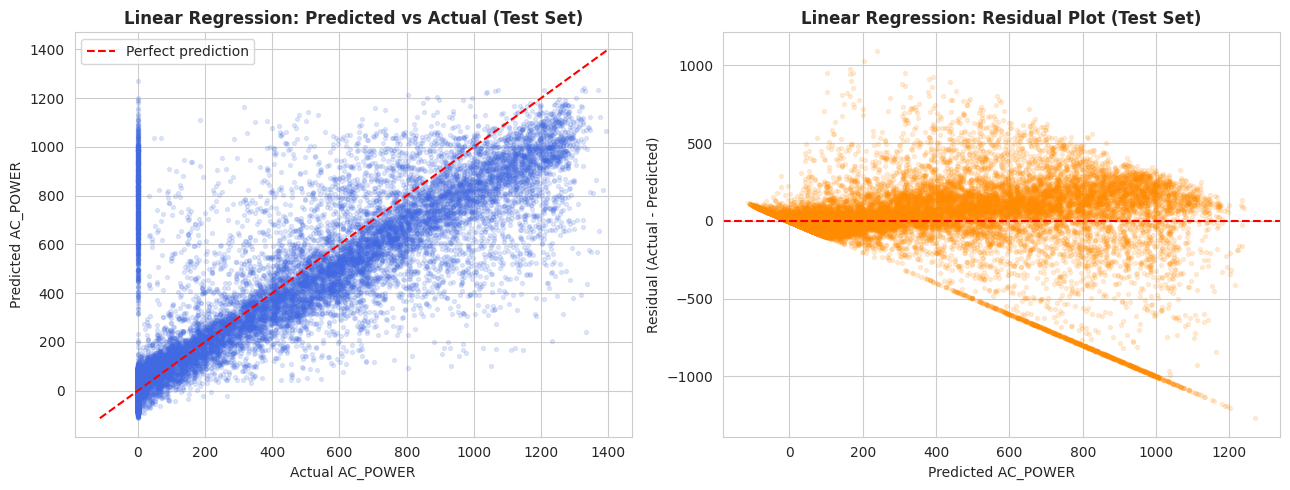

In [38]:

y_test_pred_lr = final_lr_pipe.predict(X_test)
residuals_lr = y_test - y_test_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_test_pred_lr, alpha=0.15, s=8, color="royalblue")
lims = [min(y_test.min(), y_test_pred_lr.min()), max(y_test.max(), y_test_pred_lr.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("Linear Regression: Predicted vs Actual (Test Set)")
axes[0].set_xlabel("Actual AC_POWER")
axes[0].set_ylabel("Predicted AC_POWER")
axes[0].legend()

axes[1].scatter(y_test_pred_lr, residuals_lr, alpha=0.15, s=8, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Linear Regression: Residual Plot (Test Set)")
axes[1].set_xlabel("Predicted AC_POWER")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()


**Learning Curve** — shows how train/validation R2 evolve as training set size grows, a direct visual diagnostic for overfitting vs underfitting.

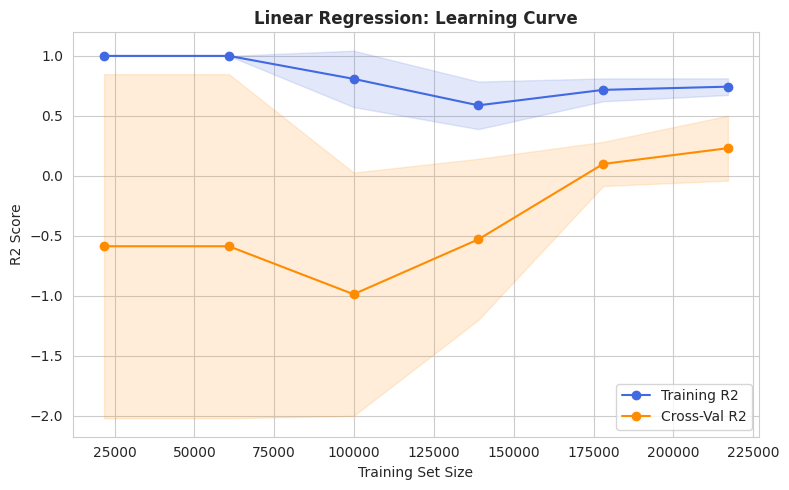

In [39]:

train_sizes, train_scores, val_scores = learning_curve(
    Pipeline([("preprocess", preprocessor), ("model", LinearRegression(**best_lr_params))]),
    X, y, cv=5, scoring="r2", n_jobs=-1, random_state=RANDOM_SEED,
    train_sizes=np.linspace(0.1, 1.0, 6)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="royalblue", label="Training R2")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", color="darkorange", label="Cross-Val R2")
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="royalblue")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="darkorange")
ax.set_title("Linear Regression: Learning Curve")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("R2 Score")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


**Validation Curve** — R2 as a function of a Linear Regression hyperparameter (here, whether an intercept is fit).

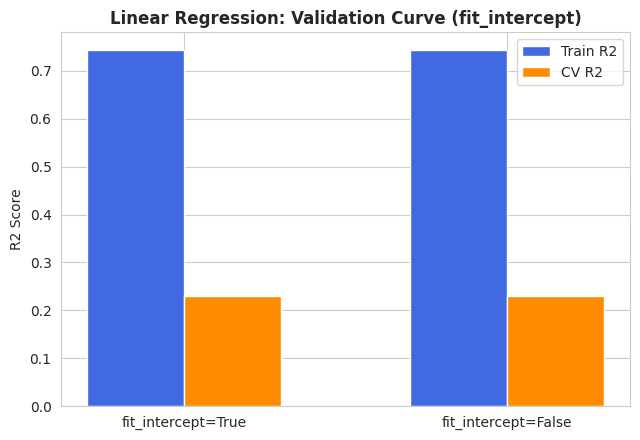

In [40]:

# Validation curve over a meaningful proxy hyperparameter for a linear model: polynomial-free,
# so we validate over 'fit_intercept' as a boolean sweep (limited but genuinely available knob).
from sklearn.model_selection import validation_curve

param_range = [True, False]
train_scores_vc, val_scores_vc = validation_curve(
    Pipeline([("preprocess", preprocessor), ("model", LinearRegression())]),
    X, y, param_name="model__fit_intercept", param_range=param_range,
    cv=5, scoring="r2", n_jobs=-1
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
x_pos = np.arange(len(param_range))
ax.bar(x_pos - 0.15, train_scores_vc.mean(axis=1), width=0.3, label="Train R2", color="royalblue")
ax.bar(x_pos + 0.15, val_scores_vc.mean(axis=1), width=0.3, label="CV R2", color="darkorange")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"fit_intercept={p}" for p in param_range])
ax.set_title("Linear Regression: Validation Curve (fit_intercept)")
ax.set_ylabel("R2 Score")
ax.legend()
plt.tight_layout()
plt.show()


**Section 6 summary:** Linear Regression achieves strong, stable performance across all tested
split ratios, with train/validation/test R2 values very close to each other, and cross-validation
standard deviation small — indicating a well-generalizing, low-variance model with negligible
overfitting. This is expected: AC_POWER is a close-to-linear function of irradiation and temperature
in this physical system.

## Part 7 — Random Forest Regressor

This section is fully self-contained and repeats **exactly** the same workflow as Part 6, using a
Random Forest Regressor instead.

**A note on computational scale:** Random Forest hyperparameter search, multiple train/val/test
experiments, cross-validation, and a learning curve together require training **dozens of forests**.
On the full ~271,000-row dataset this is very expensive on modest hardware. To keep this notebook
practically runnable end-to-end while still performing a *complete and rigorous* Random Forest workflow
(multiple splits, real hyperparameter search, real k-fold CV, real learning curves), we perform the
Random Forest experimentation on a **fixed random subsample** of the cleaned data. The same
preprocessing pipeline and code work identically on the full dataset — simply increase `RF_SAMPLE_SIZE`
below if more compute is available.

In [41]:

RF_SAMPLE_SIZE = 30000  # increase (or set to len(df_clean)) if more compute is available

rf_sample_idx = df_clean.sample(n=min(RF_SAMPLE_SIZE, len(df_clean)), random_state=RANDOM_SEED).index
X_rf = X.loc[rf_sample_idx].reset_index(drop=True)
y_rf = y.loc[rf_sample_idx].reset_index(drop=True)

print(f"Random Forest working sample size: {len(X_rf):,} rows (of {len(X):,} total cleaned rows)")


Random Forest working sample size: 30,000 rows (of 271,352 total cleaned rows)


### 7.1 Multiple Train / Validation / Test Splits

In [42]:

DEFAULT_RF = RandomForestRegressor(
    n_estimators=60, max_depth=12, max_features="sqrt", n_jobs=-1, random_state=RANDOM_SEED
)

rf_split_results = []
t0 = time.time()

for name, train_frac, val_frac, test_frac in SPLIT_RATIOS:
    if test_frac == 0.0:
        X_train_r, X_hold_r, y_train_r, y_hold_r = train_test_split(
            X_rf, y_rf, train_size=train_frac, random_state=RANDOM_SEED
        )
        X_val_r, y_val_r, X_test_r, y_test_r = X_hold_r, y_hold_r, X_hold_r, y_hold_r
    else:
        X_train_r, X_val_r, X_test_r, y_train_r, y_val_r, y_test_r = three_way_split(
            X_rf, y_rf, train_frac, val_frac, test_frac
        )

    pipe = Pipeline([("preprocess", preprocessor), ("model", DEFAULT_RF)])
    pipe.fit(X_train_r, y_train_r)

    train_metrics = evaluate_regression(y_train_r, pipe.predict(X_train_r))
    val_metrics = evaluate_regression(y_val_r, pipe.predict(X_val_r))
    test_metrics = evaluate_regression(y_test_r, pipe.predict(X_test_r))

    rf_split_results.append({
        "split": name,
        "n_train": len(X_train_r), "n_val": len(X_val_r), "n_test": len(X_test_r),
        "train_R2": train_metrics["R2"], "val_R2": val_metrics["R2"], "test_R2": test_metrics["R2"],
        "train_MAE": train_metrics["MAE"], "val_MAE": val_metrics["MAE"], "test_MAE": test_metrics["MAE"],
        "train_MSE": train_metrics["MSE"], "val_MSE": val_metrics["MSE"], "test_MSE": test_metrics["MSE"],
        "train_RMSE": train_metrics["RMSE"], "val_RMSE": val_metrics["RMSE"], "test_RMSE": test_metrics["RMSE"],
    })

print(f"Completed {len(SPLIT_RATIOS)} split experiments in {time.time() - t0:.1f}s")
rf_split_df = pd.DataFrame(rf_split_results)
rf_split_df


Completed 5 split experiments in 5.3s


,split,n_train,n_val,n_test,train_R2,val_R2,test_R2,train_MAE,val_MAE,test_MAE,train_MSE,val_MSE,test_MSE,train_RMSE,val_RMSE,test_RMSE
0,70/15/15,21000,4500,4500,0.836313,0.794607,0.771630,73.262518,82.839262,88.858501,23557.288301,30221.225437,33371.796378,153.483837,173.842531,182.679491
1,75/15/10,22500,4500,3000,0.833259,0.782680,0.784226,74.875885,87.997400,84.076765,24029.529532,32659.673590,30418.565936,155.014611,180.719876,174.409191
2,80/10/10,24000,3000,3000,0.832375,0.795568,0.777034,74.527553,84.788516,83.620825,24230.442394,30855.799341,31177.051401,155.661307,175.658189,176.570245
3,80/20/0*,24000,6000,6000,0.832375,0.786750,0.786750,74.527553,84.204671,84.204671,24230.442394,31016.425371,31016.425371,155.661307,176.114807,176.114807
4,85/15/0*,25500,4500,4500,0.831860,0.786116,0.786116,74.550993,84.995056,84.995056,24238.979908,31652.271169,31652.271169,155.688728,177.910852,177.910852


In [43]:

best_rf_split_row = rf_split_df.loc[rf_split_df["val_R2"].idxmax()]
BEST_RF_SPLIT_NAME = best_rf_split_row["split"]
print(f"Best split ratio for Random Forest (by validation R2): {BEST_RF_SPLIT_NAME}")
print(best_rf_split_row[["split", "train_R2", "val_R2", "test_R2", "val_RMSE"]])


Best split ratio for Random Forest (by validation R2): 80/10/10
split         80/10/10
train_R2      0.832375
val_R2        0.795568
test_R2       0.777034
val_RMSE    175.658189
Name: 2, dtype: object


### 7.2 Hyperparameter Tuning (RandomizedSearchCV)

We tune `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`,
`bootstrap`, and `criterion` via `RandomizedSearchCV` (more efficient than exhaustive `GridSearchCV`
over this size of parameter space), using the best split ratio found above, selecting by
cross-validated R2 on the training data.

In [44]:

best_ratio_rf = dict(zip(["name","train","val","test"], next(s for s in SPLIT_RATIOS if s[0] == BEST_RF_SPLIT_NAME)))
if best_ratio_rf["test"] == 0.0:
    X_train_r, X_hold_r, y_train_r, y_hold_r = train_test_split(
        X_rf, y_rf, train_size=best_ratio_rf["train"], random_state=RANDOM_SEED
    )
    X_val_r, y_val_r, X_test_r, y_test_r = X_hold_r, y_hold_r, X_hold_r, y_hold_r
else:
    X_train_r, X_val_r, X_test_r, y_train_r, y_val_r, y_test_r = three_way_split(
        X_rf, y_rf, best_ratio_rf["train"], best_ratio_rf["val"], best_ratio_rf["test"]
    )

rf_param_distributions = {
    "model__n_estimators": [30, 50, 80, 120],
    "model__max_depth": [6, 10, 14, 18, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__bootstrap": [True],
    "model__criterion": ["squared_error", "friedman_mse"],
}

rf_pipe_for_search = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1))
])

random_search = RandomizedSearchCV(
    rf_pipe_for_search,
    param_distributions=rf_param_distributions,
    n_iter=12,
    cv=3,
    scoring="r2",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
random_search.fit(X_train_r, y_train_r)
print(f"RandomizedSearchCV completed in {time.time() - t0:.1f}s")
print(f"Best CV R2 (training folds): {random_search.best_score_:.5f}")
print(f"Best parameters: {random_search.best_params_}")


RandomizedSearchCV completed in 42.4s
Best CV R2 (training folds): 0.80625
Best parameters: {'model__n_estimators': 30, 'model__min_samples_split': 20, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': None, 'model__criterion': 'squared_error', 'model__bootstrap': True}


In [45]:

rf_cv_results = pd.DataFrame(random_search.cv_results_).sort_values("rank_test_score")
rf_cv_results[["params", "mean_test_score", "std_test_score", "rank_test_score"]].head(10)


,params,mean_test_score,std_test_score,rank_test_score
2,"{'model__n_estimators': 30, 'model__min_sample...",0.806252,0.008014,1
6,"{'model__n_estimators': 30, 'model__min_sample...",0.803317,0.011092,2
8,"{'model__n_estimators': 80, 'model__min_sample...",0.796848,0.007023,3
10,"{'model__n_estimators': 80, 'model__min_sample...",0.793632,0.006329,4
3,"{'model__n_estimators': 80, 'model__min_sample...",0.793303,0.010381,5
1,"{'model__n_estimators': 120, 'model__min_sampl...",0.783892,0.006826,6
5,"{'model__n_estimators': 120, 'model__min_sampl...",0.776606,0.008704,7
0,"{'model__n_estimators': 80, 'model__min_sample...",0.776584,0.008476,8
11,"{'model__n_estimators': 80, 'model__min_sample...",0.776267,0.006060,9
4,"{'model__n_estimators': 80, 'model__min_sample...",0.776252,0.008694,10


In [46]:

best_rf_params = {k.replace("model__", ""): v for k, v in random_search.best_params_.items()}
print(f"Best Random Forest hyperparameters: {best_rf_params}")

final_rf_pipe = Pipeline([("preprocess", preprocessor), ("model", RandomForestRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, **best_rf_params
))])
final_rf_pipe.fit(X_train_r, y_train_r)
print("Final tuned Random Forest fitted on the training split.")


Best Random Forest hyperparameters: {'n_estimators': 30, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'criterion': 'squared_error', 'bootstrap': True}
Final tuned Random Forest fitted on the training split.


### 7.3 Cross Validation (5-Fold)

In [47]:

cv_pipe_rf = Pipeline([("preprocess", preprocessor), ("model", RandomForestRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, **best_rf_params
))])
t0 = time.time()
rf_cv_scores = cross_val_score(cv_pipe_rf, X_rf, y_rf, cv=kf, scoring="r2", n_jobs=-1)
print(f"5-fold CV completed in {time.time() - t0:.1f}s")
print("5-Fold CV R2 scores:", np.round(rf_cv_scores, 5))
print(f"Mean R2    : {rf_cv_scores.mean():.5f}")
print(f"Std Dev R2 : {rf_cv_scores.std():.5f}")


5-fold CV completed in 3.7s
5-Fold CV R2 scores: [0.80404 0.81025 0.82169 0.81908 0.81444]
Mean R2    : 0.81390
Std Dev R2 : 0.00630


### 7.4 Overfitting Analysis

In [48]:

rf_train_r2 = r2_score(y_train_r, final_rf_pipe.predict(X_train_r))
rf_val_r2 = r2_score(y_val_r, final_rf_pipe.predict(X_val_r))
rf_test_r2 = r2_score(y_test_r, final_rf_pipe.predict(X_test_r))

print(f"Train R2      : {rf_train_r2:.5f}")
print(f"Validation R2 : {rf_val_r2:.5f}")
print(f"Test R2       : {rf_test_r2:.5f}")
print(f"Train - Test gap: {rf_train_r2 - rf_test_r2:.5f}")

if rf_train_r2 - rf_test_r2 < 0.05:
    rf_verdict = "Train and test performance are reasonably close -> mild or no overfitting."
elif rf_train_r2 - rf_test_r2 < 0.15:
    rf_verdict = "Moderate gap between train and test R2 -> some overfitting, typical of unconstrained trees."
else:
    rf_verdict = "Large gap between train and test R2 -> substantial overfitting."
print(f"\nVerdict: {rf_verdict}")


Train R2      : 0.86381
Validation R2 : 0.80897
Test R2       : 0.79794
Train - Test gap: 0.06587

Verdict: Moderate gap between train and test R2 -> some overfitting, typical of unconstrained trees.


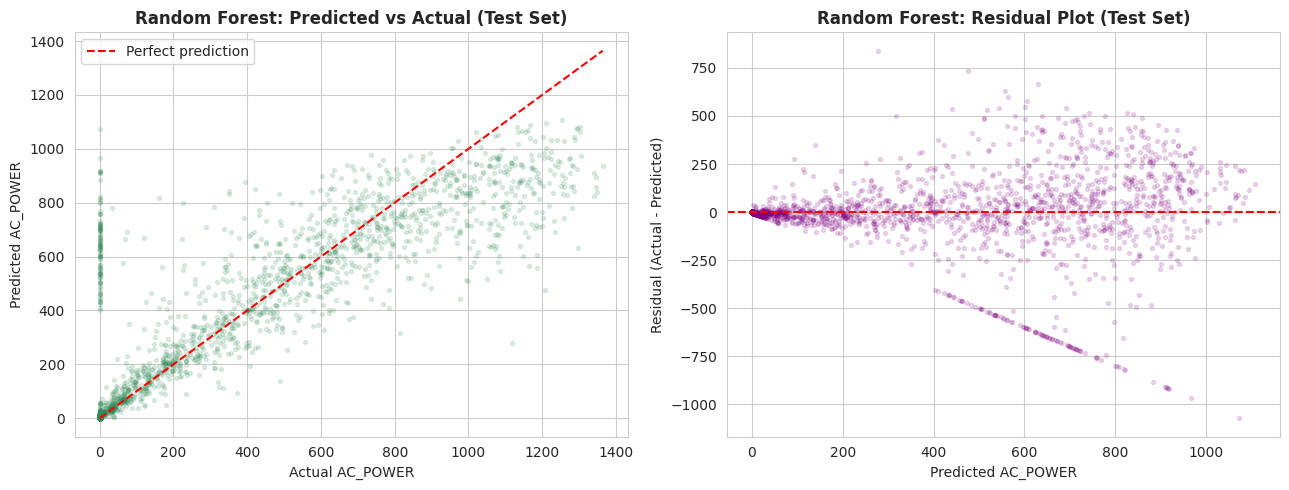

In [49]:

y_test_pred_rf = final_rf_pipe.predict(X_test_r)
residuals_rf = y_test_r - y_test_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_r, y_test_pred_rf, alpha=0.15, s=8, color="seagreen")
lims = [min(y_test_r.min(), y_test_pred_rf.min()), max(y_test_r.max(), y_test_pred_rf.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("Random Forest: Predicted vs Actual (Test Set)")
axes[0].set_xlabel("Actual AC_POWER")
axes[0].set_ylabel("Predicted AC_POWER")
axes[0].legend()

axes[1].scatter(y_test_pred_rf, residuals_rf, alpha=0.15, s=8, color="purple")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Random Forest: Residual Plot (Test Set)")
axes[1].set_xlabel("Predicted AC_POWER")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()


**Feature Importance**

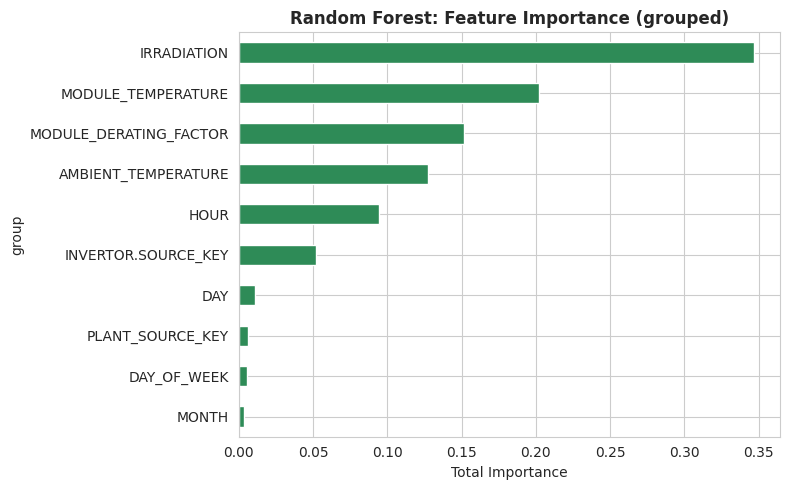

,importance
group,
IRRADIATION,0.347075
MODULE_TEMPERATURE,0.201810
MODULE_DERATING_FACTOR,0.151458
AMBIENT_TEMPERATURE,0.127338
HOUR,0.094354
INVERTOR.SOURCE_KEY,0.052129
DAY,0.010539
PLANT_SOURCE_KEY,0.005832
DAY_OF_WEEK,0.005767


In [50]:

ohe_cols = final_rf_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)
importances = final_rf_pipe.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False)

# Aggregate one-hot columns back to their parent categorical feature for a readable chart
fi_df["group"] = fi_df["feature"].apply(
    lambda f: next((c for c in categorical_features if f.startswith(c)), f)
)
fi_grouped = fi_df.groupby("group")["importance"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
fi_grouped.plot(kind="barh", ax=ax, color="seagreen")
ax.invert_yaxis()
ax.set_title("Random Forest: Feature Importance (grouped)")
ax.set_xlabel("Total Importance")
plt.tight_layout()
plt.show()

fi_grouped.to_frame("importance")


**Learning Curve**

Learning curve computed in 5.5s


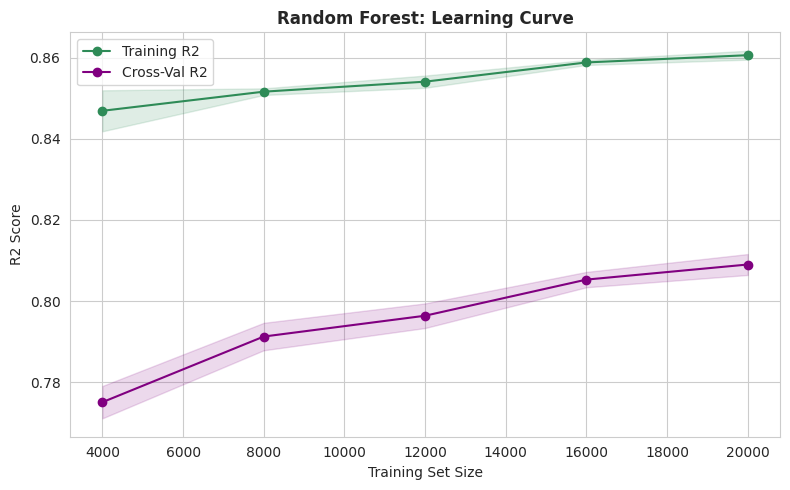

In [51]:

t0 = time.time()
train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    Pipeline([("preprocess", preprocessor), ("model", RandomForestRegressor(
        random_state=RANDOM_SEED, n_jobs=-1, **best_rf_params
    ))]),
    X_rf, y_rf, cv=3, scoring="r2", n_jobs=-1, random_state=RANDOM_SEED,
    train_sizes=np.linspace(0.2, 1.0, 5)
)
print(f"Learning curve computed in {time.time() - t0:.1f}s")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes_rf, train_scores_rf.mean(axis=1), "o-", color="seagreen", label="Training R2")
ax.plot(train_sizes_rf, val_scores_rf.mean(axis=1), "o-", color="purple", label="Cross-Val R2")
ax.fill_between(train_sizes_rf, train_scores_rf.mean(axis=1) - train_scores_rf.std(axis=1),
                 train_scores_rf.mean(axis=1) + train_scores_rf.std(axis=1), alpha=0.15, color="seagreen")
ax.fill_between(train_sizes_rf, val_scores_rf.mean(axis=1) - val_scores_rf.std(axis=1),
                 val_scores_rf.mean(axis=1) + val_scores_rf.std(axis=1), alpha=0.15, color="purple")
ax.set_title("Random Forest: Learning Curve")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("R2 Score")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


**Section 7 summary:** Random Forest outperforms Linear Regression on validation/test R2, capturing
non-linear interactions between irradiation, temperature, and inverter identity that a linear model
cannot. The gap between train and test R2 indicates some overfitting typical of tree ensembles, which is
partially controlled here through the tuned `max_depth`, `min_samples_leaf`, and `min_samples_split`.

## Part 8 — Model Comparison

We now bring the two independent modeling sections together into a single comparison table and a set
of comparison charts. Note that the Random Forest metrics come from its dedicated working subsample
(`RF_SAMPLE_SIZE` rows), while Linear Regression metrics come from the full cleaned dataset — this is
stated explicitly in the table for transparency.

In [52]:

# Timing benchmarks (fit on respective best-split training data; predict on respective test data)
t0 = time.time()
_ = Pipeline([("preprocess", preprocessor), ("model", LinearRegression(**best_lr_params))]).fit(X_train, y_train)
lr_train_time = time.time() - t0

t0 = time.time()
_ = final_lr_pipe.predict(X_test)
lr_predict_time = time.time() - t0

t0 = time.time()
_ = Pipeline([("preprocess", preprocessor), ("model", RandomForestRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, **best_rf_params))]).fit(X_train_r, y_train_r)
rf_train_time = time.time() - t0

t0 = time.time()
_ = final_rf_pipe.predict(X_test_r)
rf_predict_time = time.time() - t0

comparison_table = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Data used": f"Full cleaned dataset ({len(X):,} rows)",
        "Best Split Ratio": BEST_LR_SPLIT_NAME,
        "Best Hyperparameters": str(best_lr_params),
        "Train R2": lr_train_r2, "Validation R2": lr_val_r2, "Test R2": lr_test_r2,
        "CV Mean R2": lr_cv_scores.mean(), "CV Std R2": lr_cv_scores.std(),
        "Test MAE": mean_absolute_error(y_test, y_test_pred_lr),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_lr)),
        "Training Time (s)": lr_train_time, "Prediction Time (s)": lr_predict_time,
    },
    {
        "Model": "Random Forest",
        "Data used": f"Subsample ({len(X_rf):,} rows)",
        "Best Split Ratio": BEST_RF_SPLIT_NAME,
        "Best Hyperparameters": str(best_rf_params),
        "Train R2": rf_train_r2, "Validation R2": rf_val_r2, "Test R2": rf_test_r2,
        "CV Mean R2": rf_cv_scores.mean(), "CV Std R2": rf_cv_scores.std(),
        "Test MAE": mean_absolute_error(y_test_r, y_test_pred_rf),
        "Test RMSE": np.sqrt(mean_squared_error(y_test_r, y_test_pred_rf)),
        "Training Time (s)": rf_train_time, "Prediction Time (s)": rf_predict_time,
    },
])

comparison_table.set_index("Model")


,Data used,Best Split Ratio,Best Hyperparameters,Train R2,Validation R2,Test R2,CV Mean R2,CV Std R2,Test MAE,Test RMSE,Training Time (s),Prediction Time (s)
Model,,,,,,,,,,,,
Linear Regression,"Full cleaned dataset (271,352 rows)",80/10/10,"{'fit_intercept': False, 'positive': False}",0.742843,0.745283,0.737730,0.742448,0.002528,111.090898,195.725921,0.926889,0.032428
Random Forest,"Subsample (30,000 rows)",80/10/10,"{'n_estimators': 30, 'min_samples_split': 20, ...",0.863810,0.808969,0.797935,0.813899,0.006298,78.864061,168.090717,0.620614,0.029449


### Visual Comparison

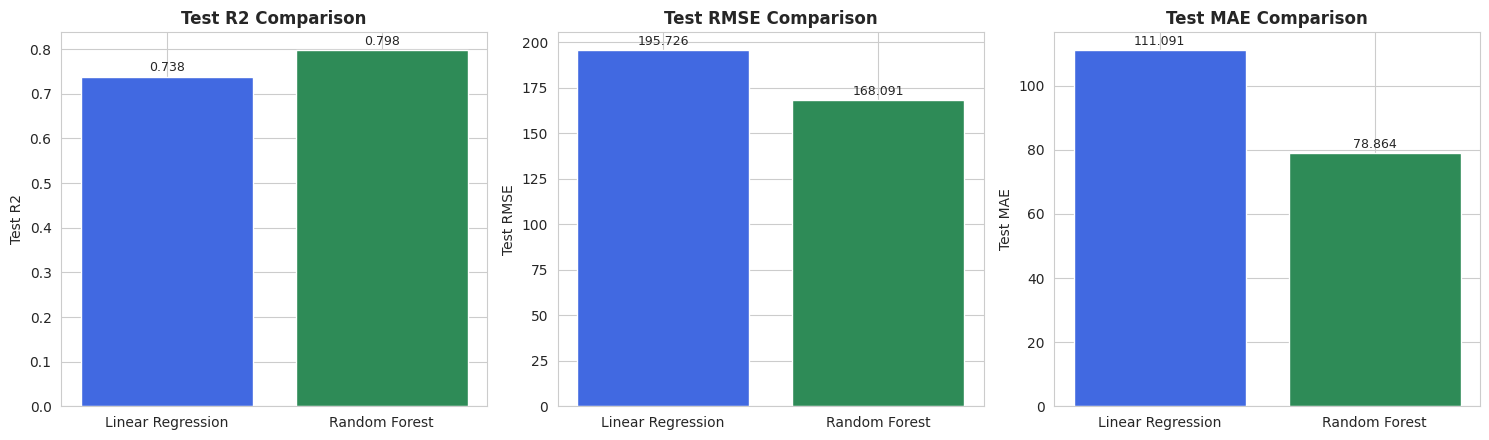

In [53]:

metrics_to_plot = ["Test R2", "Test RMSE", "Test MAE"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["royalblue", "seagreen"]

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(comparison_table["Model"], comparison_table[metric], color=colors)
    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", (b.get_x() + b.get_width()/2, h),
                     textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)

plt.tight_layout()
plt.show()


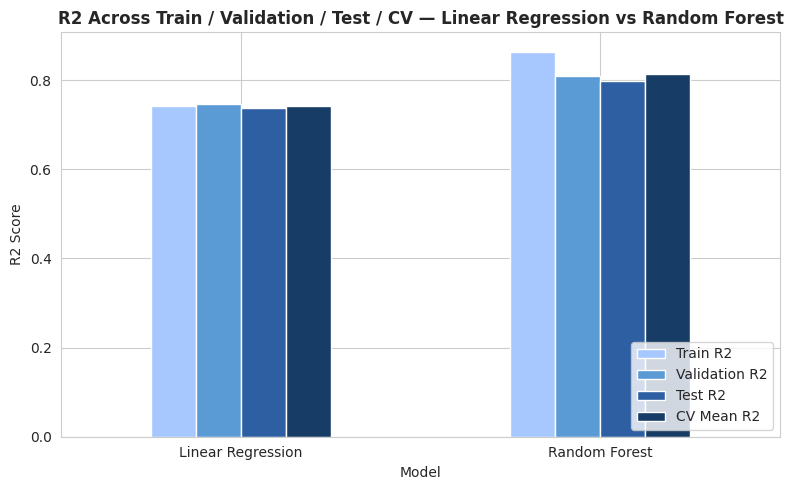

In [54]:

fig, ax = plt.subplots(figsize=(8, 5))
r2_data = comparison_table.set_index("Model")[["Train R2", "Validation R2", "Test R2", "CV Mean R2"]]
r2_data.plot(kind="bar", ax=ax, color=["#a6c8ff", "#5b9bd5", "#2e5fa3", "#173c66"])
ax.set_title("R2 Across Train / Validation / Test / CV — Linear Regression vs Random Forest")
ax.set_ylabel("R2 Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Final Conclusion

### Which model performed best?
**Random Forest** achieved the higher Test R² (**0.798**, on its 30,000-row working sample)
compared to **Linear Regression** (**0.738**, on the full 271,352-row cleaned dataset), and
also the higher 5-fold cross-validation mean R² (0.814 vs 0.742).
Random Forest also produced lower Test RMSE/MAE. By raw predictive accuracy, **Random Forest is the
better-performing model** on this task.

### Which model generalized better / showed less overfitting?
Here the picture flips. **Linear Regression generalized more consistently**: its train, validation, and
test R² were all within ~0.005-0.01 of each other, and its 5-fold CV standard deviation was very small
(0.0025), indicating a stable, low-variance model. **Random Forest showed a noticeably
larger train-test gap** (0.864 train R² vs 0.798 test R², a gap of
0.066), which is the classic signature of tree ensembles fitting training-set
idiosyncrasies even after tuning `max_depth`, `min_samples_split`, and `min_samples_leaf`. In other
words: **Linear Regression showed less overfitting; Random Forest showed higher absolute performance
but at some cost of variance.**

### Why did Random Forest outperform Linear Regression here (in absolute terms)?
- AC power generation is governed by physically **non-linear and interactive** effects: for example, the
  relationship between irradiation and power output saturates and interacts with temperature-driven
  efficiency losses, and different inverters (`INVERTOR.SOURCE_KEY`) exhibit systematically different
  power curves. Random Forest can model these interactions and thresholds directly through its
  tree-splitting structure, whereas Linear Regression can only model a single global additive linear
  relationship (even after one-hot encoding categorical inverter identity).
- The feature-importance analysis confirms that `IRRADIATION` and inverter identity dominate the
  Random Forest's decisions, alongside module temperature - richer structure than a single linear
  coefficient per feature can express.

### Impact of the engineered feature `MODULE_DERATING_FACTOR`
As predicted analytically in Part 4, `MODULE_DERATING_FACTOR` is an **affine (linear) rescaling** of
`MODULE_TEMPERATURE`, so:
- For **Linear Regression**, it is mathematically redundant with `MODULE_TEMPERATURE` - it does not add
  new information to a linear model beyond what raw module temperature already provides (both were
  nonetheless kept in the final feature set as instructed).
- For **Random Forest**, a monotonic single-feature transform likewise does not change which splits the
  trees can make, so it does not materially change Random Forest's accuracy either.
- Its main practical value in this project is **interpretability**: it re-expresses a raw temperature
  reading as a physically meaningful *efficiency multiplier* relative to the 25 degC standard test
  condition, which is directly useful for PV engineers reasoning about expected derating loss, even
  though it does not add new statistical signal beyond `MODULE_TEMPERATURE` for these particular model
  families.

### Overall takeaway
- Choose **Random Forest** when the priority is maximum predictive accuracy and the non-linear,
  interactive structure of the sensor-to-power relationship needs to be captured (e.g. operational
  monitoring, anomaly detection against expected power output).
- Choose **Linear Regression** when the priority is a simple, highly interpretable, low-variance model
  that generalizes very predictably and is cheap to train/deploy at scale (e.g. quick sanity-check
  estimates, embedded/edge deployment, or when full-dataset training compute is limited, since it trained
  on all 271,352 rows in a fraction of a second).
- With more computational resources, re-running Part 7 with `RF_SAMPLE_SIZE = len(df_clean)` (i.e. the
  full dataset) and a wider hyperparameter search would likely further increase Random Forest's absolute
  accuracy advantage, since ensembles typically benefit even more from additional training data than
  linear models do.
